In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
param_grid = {
    'model_params.hidden_layers': [(256, 128, 128, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1],
    'learning_rate': [0.00001],
    'batch_size': [64],
    'epochs': [2000]
}


In [6]:
feature_df.fillna(-1, inplace=True)

In [7]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [8]:
feature_df.shape

(2660, 2729)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(256, 128, 128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.1], 'learning_rate': [1e-05], 'batch_size': [64], 'epochs': [2000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


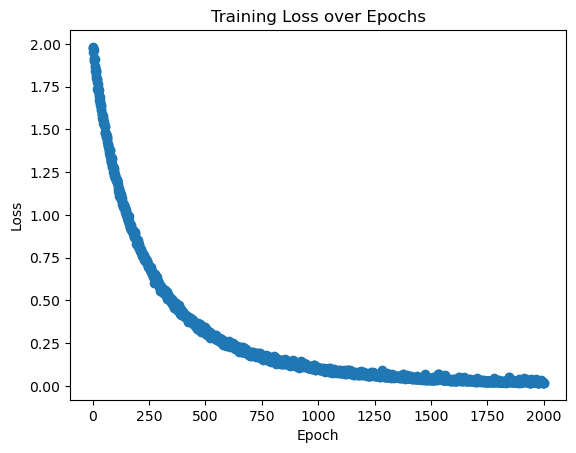

Final training loss: 0.017044542749461374
Training fold 2/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


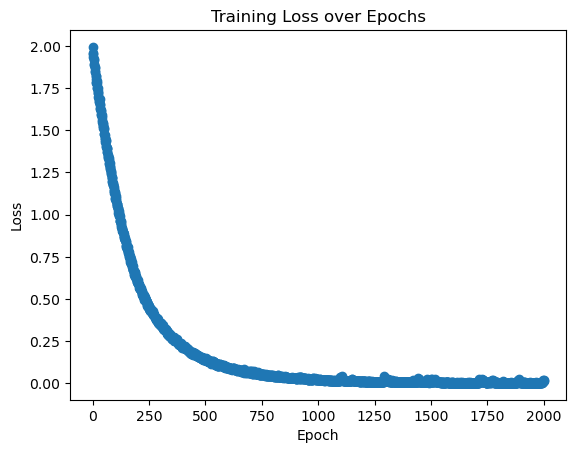

Final training loss: 0.01519484906679108
Training fold 3/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


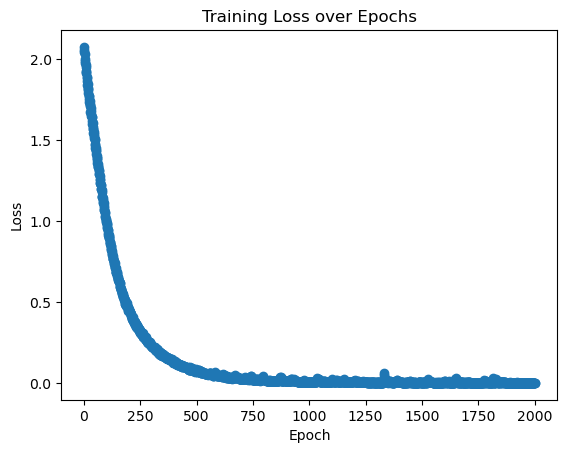

Final training loss: 0.0024771920413886794
Training fold 4/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


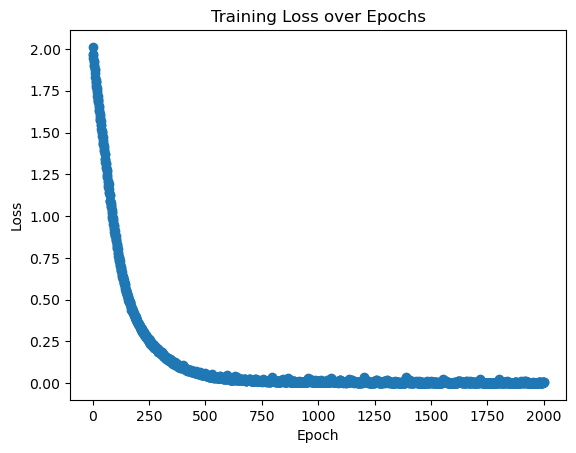

Final training loss: 0.008752580458429037
Training fold 5/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


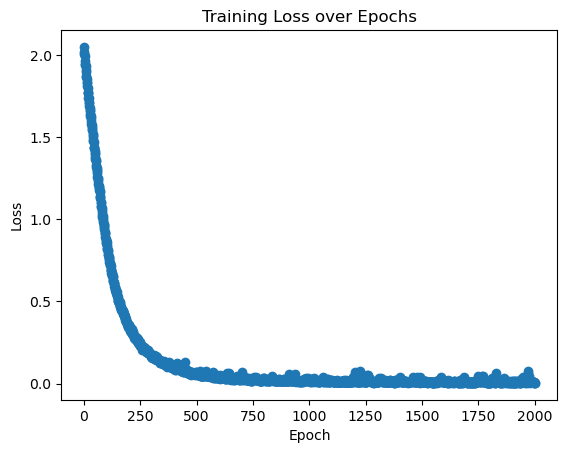

Final training loss: 0.005935926314788803
[TorchWrapper] Using device: mps


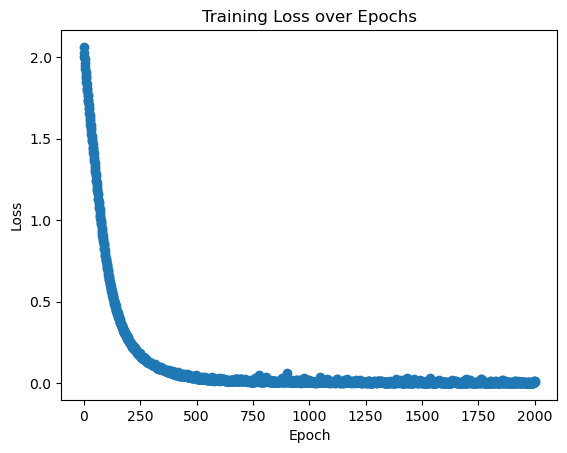

Final training loss: 0.011696367282105288
{'home_goals_train_accuracy': 0.9994987468671679, 'home_goals_train_precision': 0.9997004203525943, 'home_goals_valid_accuracy': 0.2596491228070175, 'home_goals_valid_precision': 0.1591065703759452, 'home_goals_test_accuracy': 0.2669172932330827, 'home_goals_test_precision': 0.1275257741423155, 'home_goals_train_lte_0_accuracy': 0.9994987468671679, 'home_goals_train_lte_0_accuracy_std': 0.0006139072037050435, 'home_goals_train_lte_0_precision': 0.9979029424681599, 'home_goals_train_lte_0_precision_std': 0.002571233626480518, 'home_goals_train_gt_0_accuracy': 0.9994987468671679, 'home_goals_train_gt_0_accuracy_std': 0.0006139072037050435, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.999749373433584, 'home_goals_train_gt_1_accuracy_std': 0.000501253132832069, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy

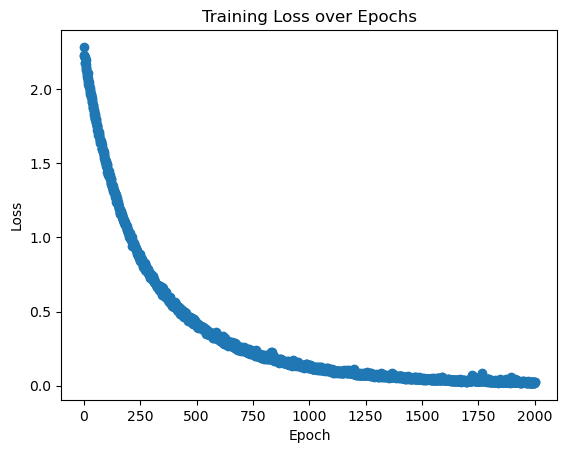

Final training loss: 0.021835701684829286
Training fold 2/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


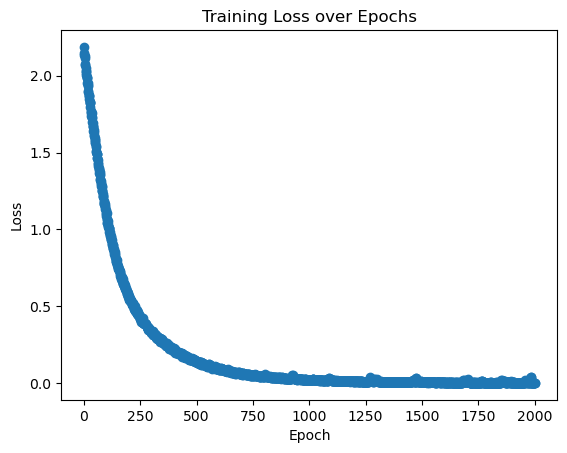

Final training loss: 0.0023864485553342072
Training fold 3/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


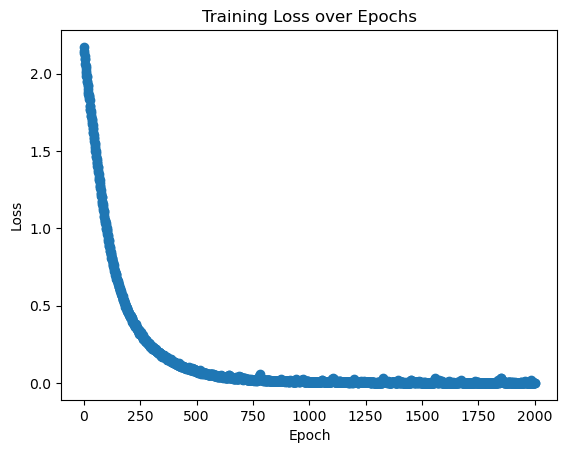

Final training loss: 0.0015266796287286128
Training fold 4/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


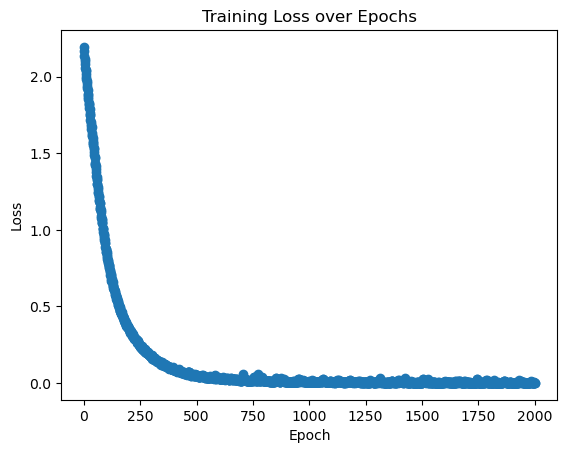

Final training loss: 0.0014952922217725288
Training fold 5/5 with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


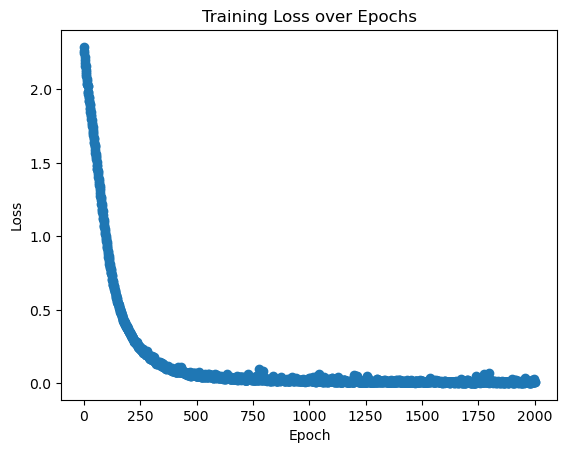

Final training loss: 0.012313115544544818
[TorchWrapper] Using device: mps


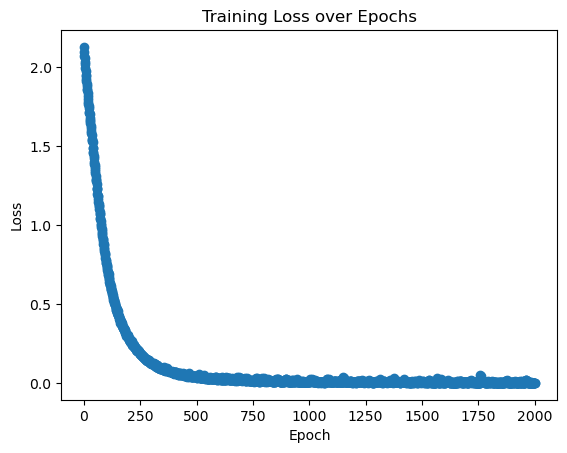

Final training loss: 0.0019738093966193367
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.29022556390977444, 'away_goals_valid_precision': 0.14688478803354815, 'away_goals_test_accuracy': 0.2669172932330827, 'away_goals_test_precision': 0.1362487188351661, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_

In [ ]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    key_columns=TRAINGING_CONFIG['key_columns'],
    save_model_path=TRAINGING_CONFIG['save_model_path']
)

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


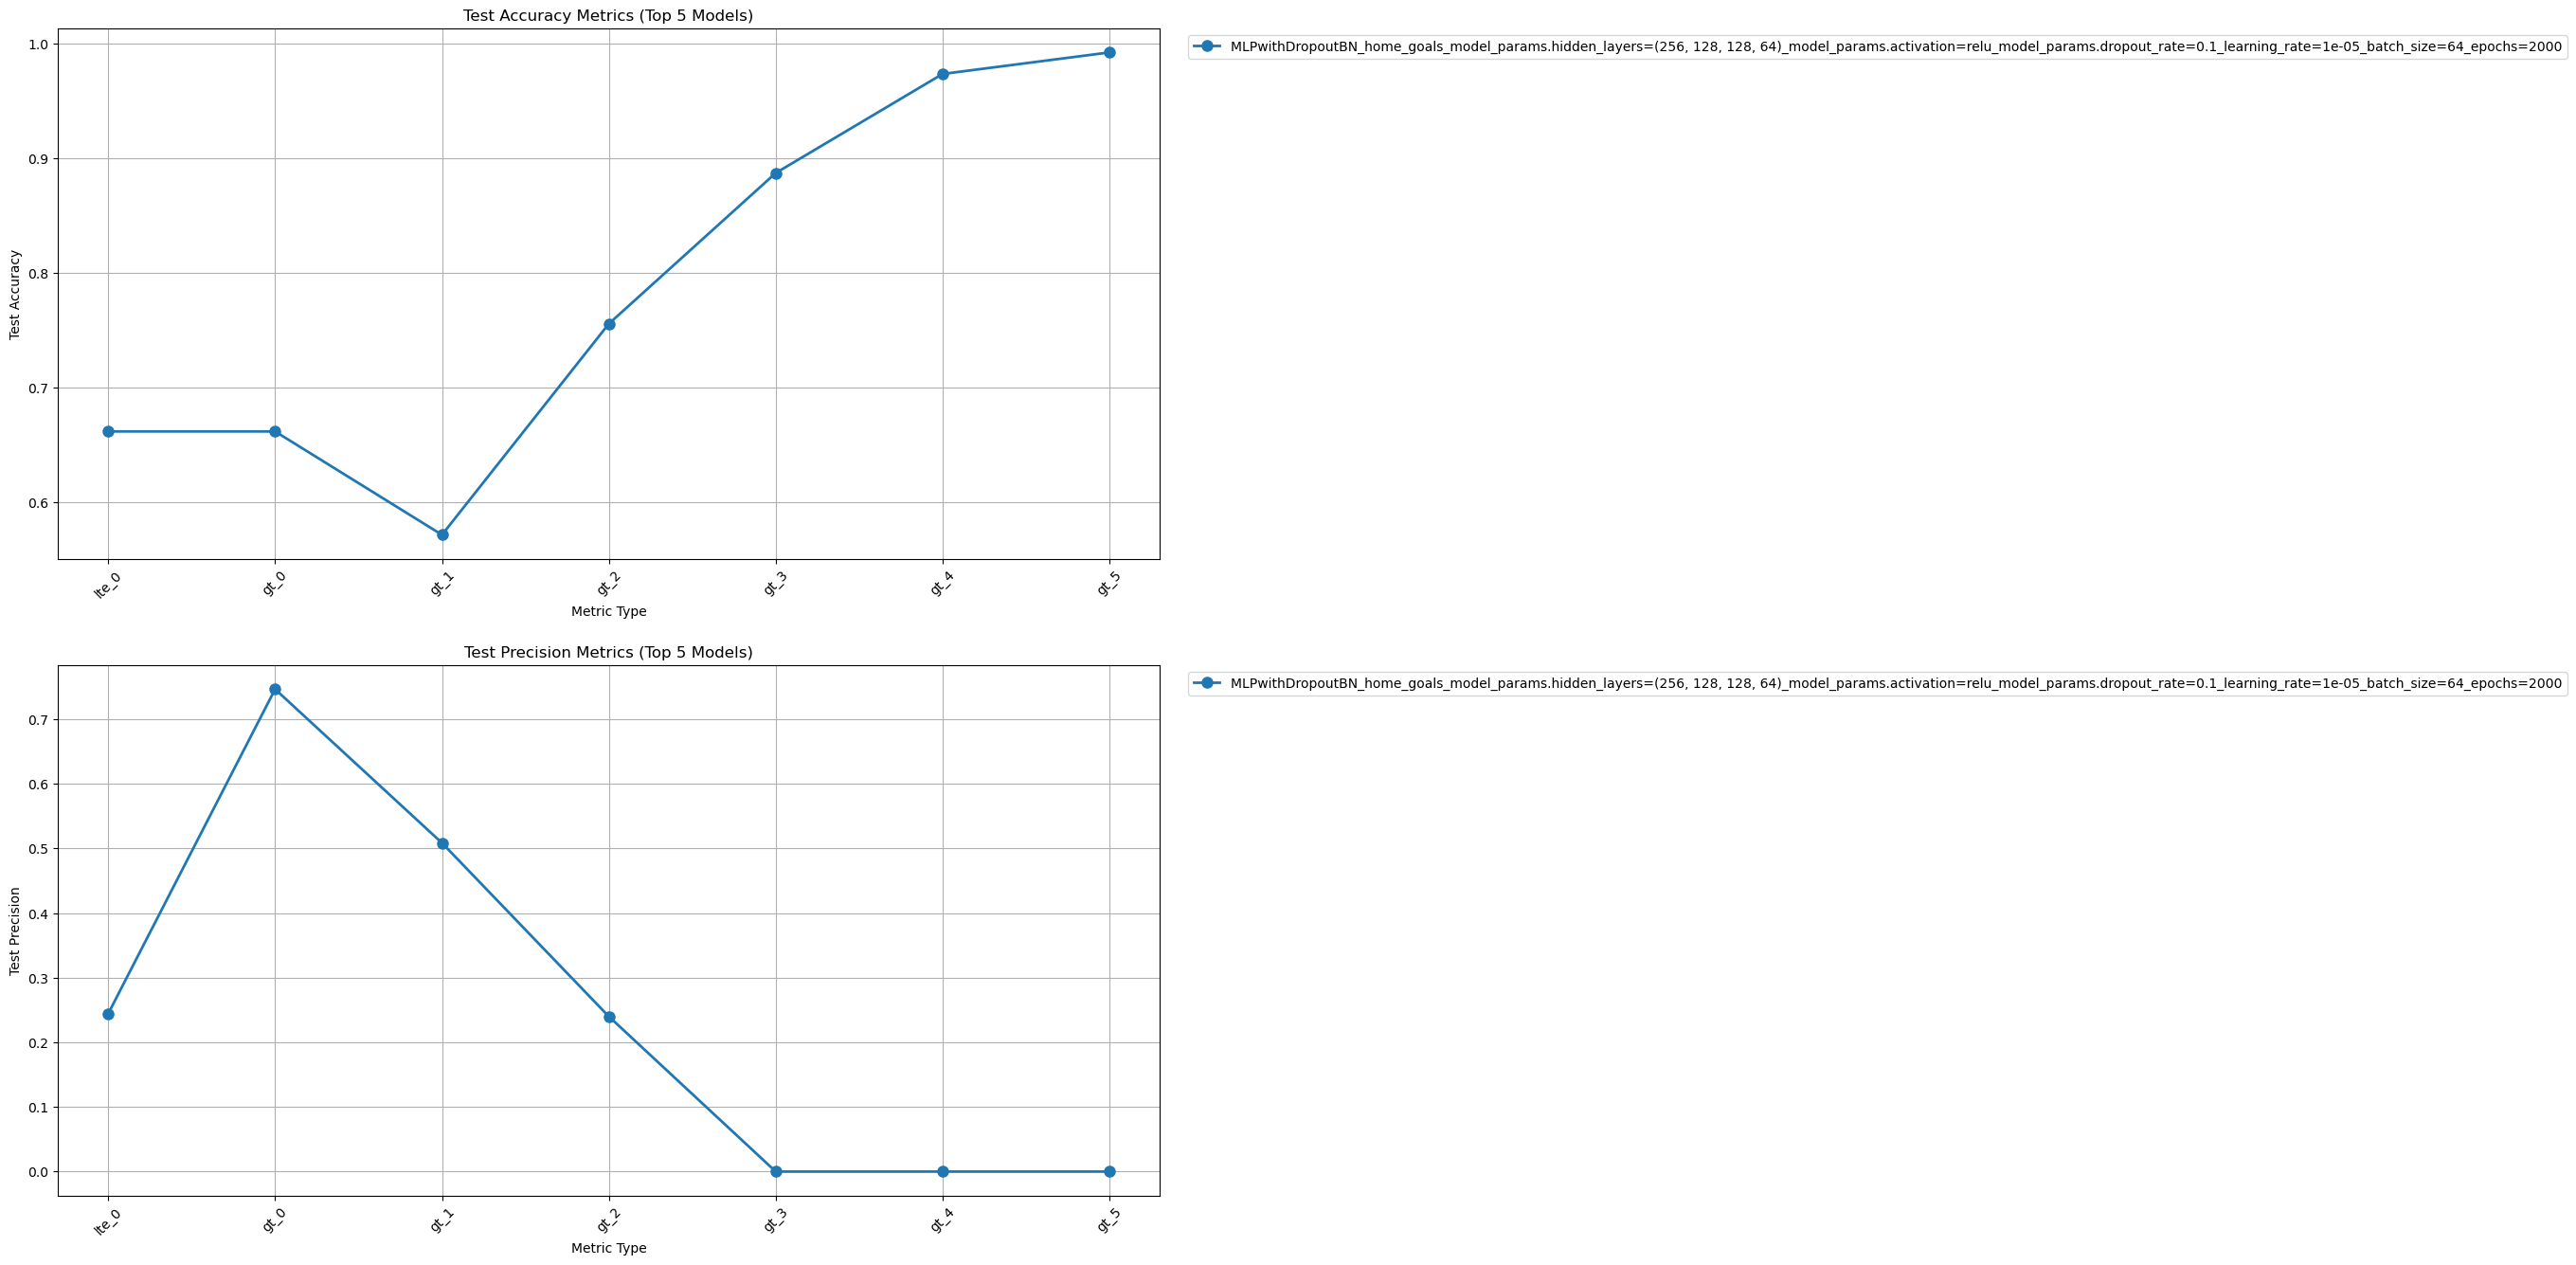

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

{'metrics.away_goals_train_gt_5_accuracy': 1.0, 'metrics.away_goals_train_accuracy': 1.0, 'metrics.away_goals_train_gt_3_accuracy': 1.0, 'metrics.away_goals_train_gt_6_accuracy': 1.0, 'metrics.away_goals_train_gt_4_accuracy': 1.0, 'metrics.away_goals_train_gt_1_accuracy': 1.0, 'metrics.away_goals_train_lte_0_accuracy': 1.0, 'metrics.away_goals_train_gt_0_accuracy': 1.0, 'metrics.away_goals_train_gt_2_accuracy': 1.0}
{'metrics.away_goals_valid_gt_3_accuracy': 0.9303258145363408, 'metrics.away_goals_valid_lte_0_accuracy': 0.612531328320802, 'metrics.away_goals_valid_gt_0_accuracy': 0.612531328320802, 'metrics.away_goals_valid_gt_2_accuracy': 0.7684210526315789, 'metrics.away_goals_valid_gt_6_accuracy': 0.9984962406015038, 'metrics.away_goals_valid_gt_4_accuracy': 0.9789473684210526, 'metrics.away_goals_valid_accuracy': 0.29022556390977444, 'metrics.away_goals_valid_gt_5_accuracy': 0.9949874686716791, 'metrics.away_goals_valid_gt_1_accuracy': 0.5789473684210527}
{'metrics.away_goals_test_

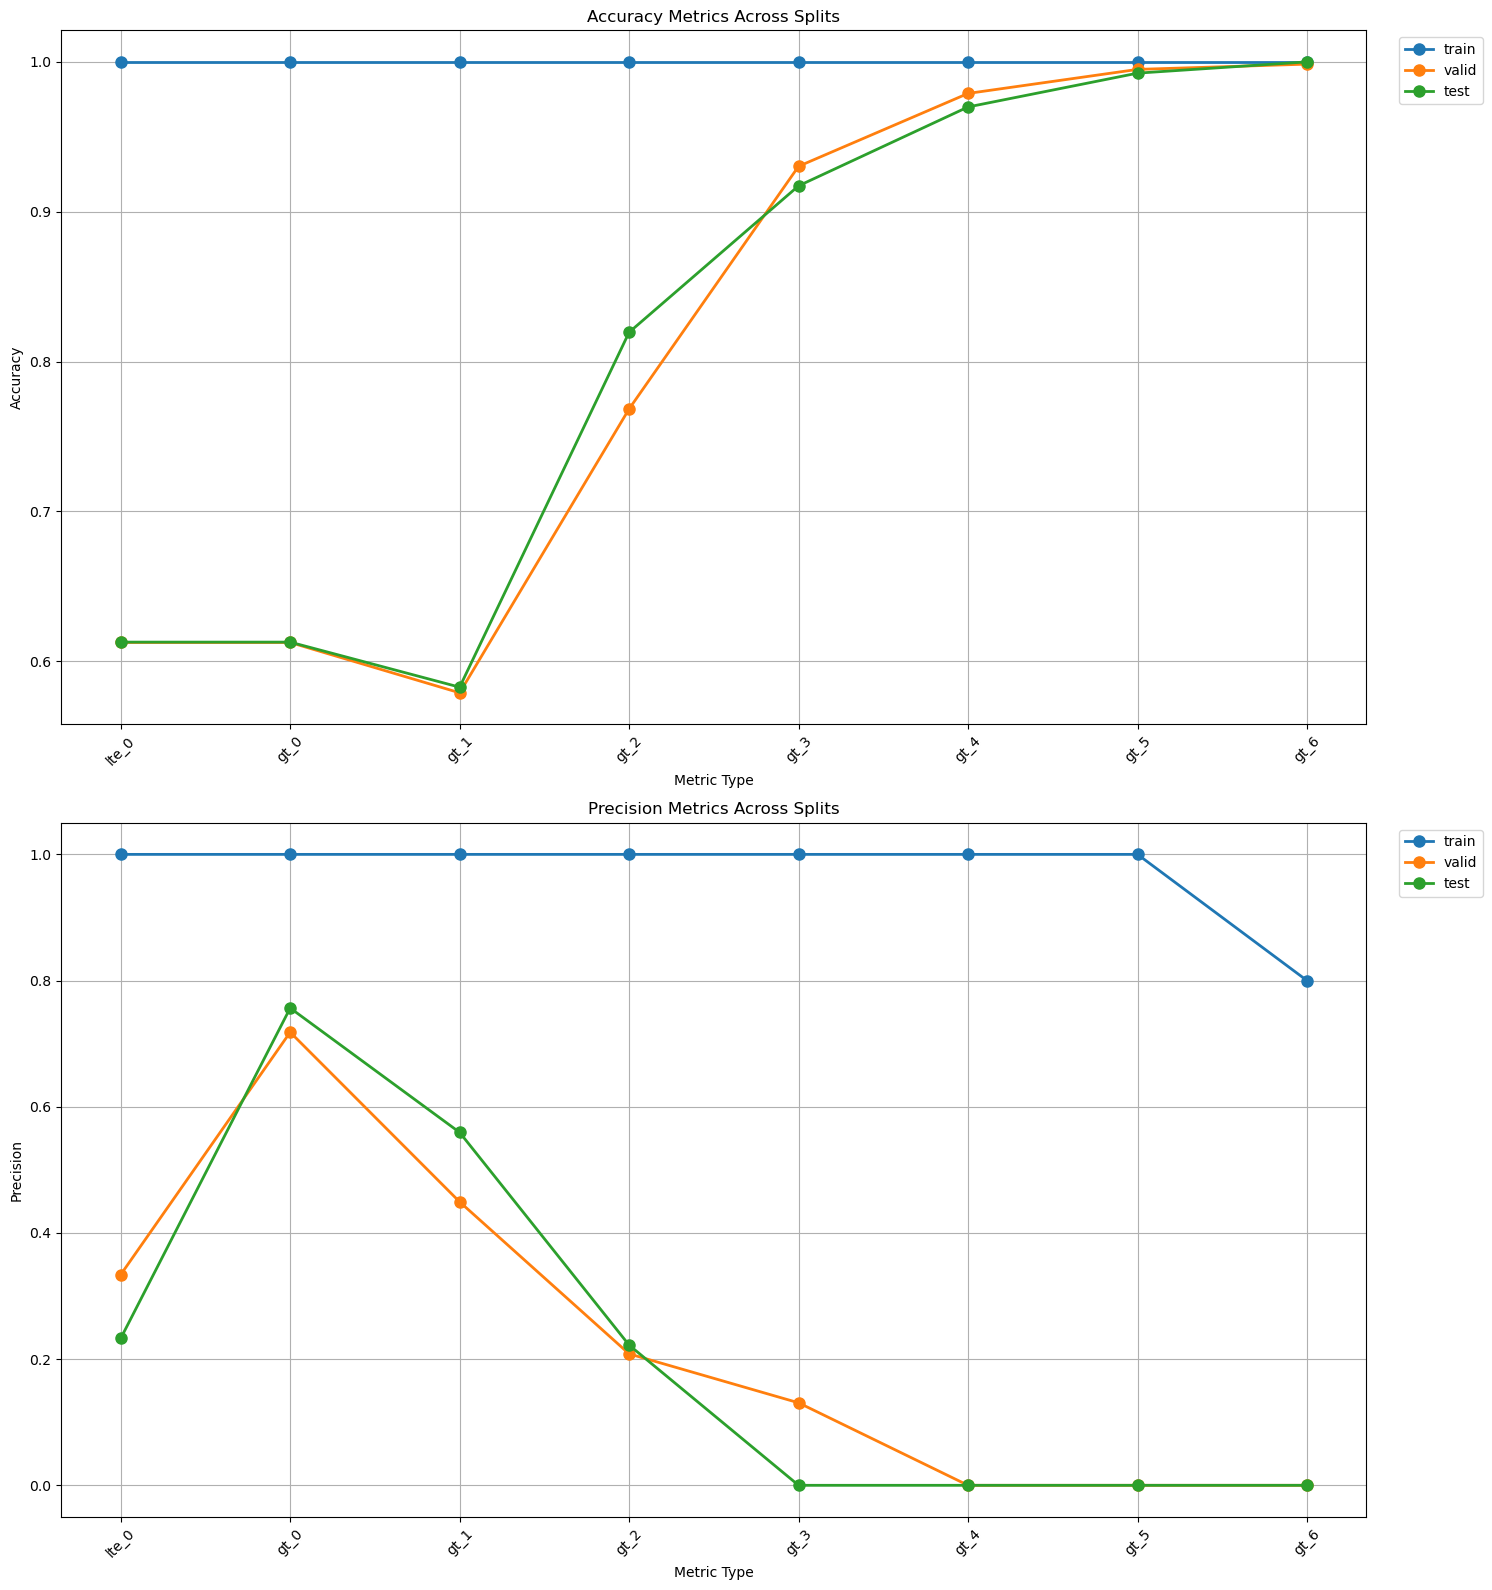

In [11]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_model_params.hidden_layers=(256, 128, 128, 64)_model_params.activation=relu_model_params.dropout_rate=0.1_learning_rate=1e-05_batch_size=64_epochs=2000",
                         target_col="away_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

In [12]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers= '(512, 256, 256, 128, 128)' and params.model_params.activation= 'relu' and params.model_params.dropout_rate= '0' and params.learning_rate= '1e-05' and params.batch_size= '64' and params.epochs= '5000'
No runs found with model_name 'MLPwithDropoutBN' and params {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}.
